# S&P 500 Options: Portfolio Construction

**Chapter 17 - Portfolio Construction**

This notebook sweeps **top predictions × TOP_K concentration × 5 alternative allocators**
to find the best portfolio configuration for the S&P 500 straddle strategy
under the same daily mark-to-market cost engine as the equal-weight baseline.
The key question is whether any allocator or concentration level meaningfully
improves on the complete liquid-universe baseline.

The current baseline has 342 complete validation runs. Allocation tests whether
reweighting improves the top ten liquid-universe configurations; it does not
revisit model selection or use holdout information.

Sections 1–2 write allocation-stage backtests to `registry.db`. Section 3
queries the registry via `BacktestExplorer` and can be re-run independently.

**Book Reference:** Chapter 17, Sections 17.2–17.8

**Prerequisites:** Completed Ch16 backtest with results in `registry.db`.

In [1]:
"""S&P 500 Options: Portfolio: Allocator Sweep."""

import sqlite3
import time
import warnings

import polars as pl

warnings.filterwarnings("ignore")

from case_studies.sp500_options.backtest_contract import (
    assert_accepted_deep_baselines,
    assert_complete_allocation_surface,
    assert_complete_baseline_surface,
)
from case_studies.utils.backtest_loaders import get_backtest_config, load_backtest_prices_for
from case_studies.utils.backtest_presets import SP500_OPTIONS_SCHEDULE_CONTRACT, build_backtest_spec
from case_studies.utils.backtest_runner import run_backtest
from case_studies.utils.registry import read_predictions, resolve_best_predictions
from case_studies.utils.sweep_config import (
    get_allocators,
    get_checkpoints_per_config,
    get_top_k_values_for,
    get_top_n_predictions,
)
from utils.paths import get_case_study_dir

In [2]:
CASE_STUDY_ID = "sp500_options"
LABEL = ""
MAX_SYMBOLS = 0
SKIP_EXPENSIVE_ALLOC = False
# Rung-3 support (mirrors 12_backtest.py): when True, restrict each rebalance
# date's prediction set to the bottom-quintile half-spread "liquid" subset, and
# tag the strategy spec with universe_filter="liquid". The flag is part of the
# backtest-hash so the two universes register independently.
LIQUID_ONLY = True
LIQUID_QUANTILE = 0.20
TOP_N_PREDICTIONS = None

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
assert_accepted_deep_baselines(CASE_DIR / "run_log" / "registry.db")
assert_complete_baseline_surface(CASE_DIR / "run_log" / "registry.db")
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_PREDICTIONS is None:
    TOP_N_PREDICTIONS = get_top_n_predictions(CASE_STUDY_ID, "allocation")
CHECKPOINTS_PER_CONFIG = get_checkpoints_per_config(CASE_STUDY_ID)
if not LABEL:
    LABEL = bt_config.primary_label

print(f"Case study: {CASE_STUDY_ID}, label: {LABEL}")

Case study: sp500_options, label: ret_to_expiry


## 1. Load the Baseline Shortlist

The ten distinct model configurations with the highest liquid-universe
equal-weight baseline Sharpe advance from notebook 12. The shortlist contains
eight linear configurations plus the accepted PatchTST and LSTM producers.
Allocation tests reweighting only and does not revisit model selection.

In [4]:
top_preds = resolve_best_predictions(
    CASE_STUDY_ID,
    LABEL,
    split="validation",
    stage="signal",
    top_n=TOP_N_PREDICTIONS,
    checkpoints_per_config=CHECKPOINTS_PER_CONFIG,
    universe_filter="liquid" if LIQUID_ONLY else "full",
)
if len(top_preds) != TOP_N_PREDICTIONS:
    raise RuntimeError(
        f"Resolved {len(top_preds)} advancing predictions, expected {TOP_N_PREDICTIONS}"
    )
print(f"Top {len(top_preds)} prediction sources by equal-weight baseline Sharpe:")
print(top_preds.select(["prediction_hash", "training_hash", "source", "sharpe"]))

Top 10 prediction sources by equal-weight baseline Sharpe:
shape: (10, 4)
┌─────────────────┬───────────────┬──────────────────────────┬───────────┐
│ prediction_hash ┆ training_hash ┆ source                   ┆ sharpe    │
│ ---             ┆ ---           ┆ ---                      ┆ ---       │
│ str             ┆ str           ┆ str                      ┆ f64       │
╞═════════════════╪═══════════════╪══════════════════════════╪═══════════╡
│ 09af9a2b2fd0    ┆ 162ece527523  ┆ linear/ridge_a10000000.0 ┆ 0.001681  │
│ 7c305d13f989    ┆ 4545276ffb4c  ┆ linear/lasso_f0.85       ┆ -0.048811 │
│ ff68b6dd6e32    ┆ b368d1bd5936  ┆ linear/ridge_a1000000.0  ┆ -0.067678 │
│ 5160121e11e5    ┆ 0c6ca489b21d  ┆ linear/enet_f0.85        ┆ -0.081878 │
│ e541700265cd    ┆ c05e7c68bfa0  ┆ linear/lasso_f0.7        ┆ -0.084074 │
│ ebe9b2d53689    ┆ 18246ebe6f9b  ┆ linear/enet_f0.7         ┆ -0.105761 │
│ 74cfdceaaa1a    ┆ 2742726b045e  ┆ linear/ridge_a100000.0   ┆ -0.230347 │
│ c592ca4defbb    ┆ b19c49

In [5]:
prices = load_backtest_prices_for(CASE_STUDY_ID, LABEL, split="validation", max_symbols=MAX_SYMBOLS)
n_assets = prices["symbol"].n_unique()
print(f"Prices: {len(prices):,} rows, {n_assets} assets")

Prices: 144,081 rows, 546 assets


### Liquidity Filter (Optional, Rung-3)

With `LIQUID_ONLY=True`, predictions are restricted each rebalance date to the
bottom quintile of relative half-spread - the tightest-quoted 20% of available
straddles. This is the O'Donovan-Yu (2024) "liquid-universe" mitigation
applied at backtest time. Mirrors the rung-3 path in `12_backtest.py`.

In [6]:
if LIQUID_ONLY:
    _half_spread = prices.select(
        pl.col("timestamp").cast(pl.Date).alias("timestamp"),
        "symbol",
        (pl.col("instr_rel_spread") / 2).alias("half_spread"),
    )
    liquid_keys = (
        _half_spread.with_columns(
            (
                pl.col("half_spread").rank("min").over("timestamp")
                / pl.col("half_spread").count().over("timestamp")
            ).alias("spread_rank_pct"),
        )
        .filter(pl.col("spread_rank_pct") <= LIQUID_QUANTILE)
        .select(["timestamp", "symbol"])
    )
    print(
        f"Liquid subset (bottom {int(LIQUID_QUANTILE * 100)}% half-spread per date): "
        f"{len(liquid_keys):,} (symbol, date) keys"
    )
else:
    liquid_keys = None

Liquid subset (bottom 20% half-spread per date): 28,623 (symbol, date) keys


## 2. Allocation Sweep

For each (prediction × TOP_K × allocator), `run_backtest()` receives an
allocation config appended to the strategy spec. The spec hash differentiates
these allocation-stage runs from signal-stage backtests in the registry.

The five alternatives range from score weighting to hierarchical risk parity.
Equal weight is excluded because notebook 12 already materialized that
baseline. Each run uses the canonical liquid universe and the same premium-cost
HTM engine, so the allocation comparison changes only within-cohort weights.

In [7]:
TOP_K_VALUES = get_top_k_values_for(CASE_STUDY_ID, LABEL, n_assets)
print(f"TOP_K grid: {TOP_K_VALUES} (universe: {n_assets} assets)")

_ALL_ALLOC_CONFIGS = [
    allocation
    for allocation in get_allocators(CASE_STUDY_ID)
    if allocation["method"] != "equal_weight"
]

_EXPENSIVE = {"mvo_ledoit_wolf", "hrp"}
if SKIP_EXPENSIVE_ALLOC:
    ALLOC_CONFIGS = [a for a in _ALL_ALLOC_CONFIGS if a["method"] not in _EXPENSIVE]
    print(f"Skipping expensive allocators: {', '.join(sorted(_EXPENSIVE))}")
else:
    ALLOC_CONFIGS = _ALL_ALLOC_CONFIGS

n_total = len(top_preds) * len(TOP_K_VALUES) * len(ALLOC_CONFIGS)
print(
    f"Total backtests: {len(top_preds)} preds × {len(TOP_K_VALUES)} top_k × "
    f"{len(ALLOC_CONFIGS)} allocs = {n_total}"
)

TOP_K grid: [5, 10, 20] (universe: 546 assets)
Total backtests: 10 preds × 3 top_k × 5 allocs = 150


Apply the canonical liquid-universe filter to one accepted prediction set.

In [8]:
def _load_allocation_predictions(prediction_hash: str) -> pl.DataFrame:
    predictions = read_predictions(CASE_STUDY_ID, prediction_hash)
    if LIQUID_ONLY and liquid_keys is not None:
        keys = liquid_keys.cast({"timestamp": predictions["timestamp"].dtype})
        predictions = predictions.join(keys, on=["timestamp", "symbol"], how="semi")
    return predictions

Run one allocator with the same holiday-aware HTM schedule contract used by
the equal-weight baseline.

In [9]:
def _run_allocation(
    prediction_hash: str,
    predictions: pl.DataFrame,
    top_k: int,
    allocation: dict,
):
    signal_cfg = {
        "method": "equal_weight_top_k",
        "top_k": top_k,
        "long_short": bt_config.long_short,
        "universe_filter": "liquid" if LIQUID_ONLY else "full",
    }
    spec = build_backtest_spec(
        CASE_STUDY_ID,
        bt_config,
        prices=prices,
        prediction_hash=prediction_hash,
        initial_cash=bt_config.initial_cash,
        chapter="ch17",
        signal=signal_cfg,
        allocation={**allocation, "top_k": top_k, "long_short": bt_config.long_short},
    )
    return run_backtest(
        CASE_STUDY_ID,
        prediction_hash,
        spec,
        prices=prices,
        predictions=predictions,
        label=LABEL,
        register=True,
        initial_cash=bt_config.initial_cash,
        calendar=bt_config.calendar,
    )

Materialize the exact 150-run allocation surface with item-level progress.

In [10]:
n_done = 0
n_failed = 0
failure_messages = []
sweep_start = time.monotonic()
for top_k in TOP_K_VALUES:
    print(f"\n--- TOP_K = {top_k} ---")
    for pred_row in top_preds.iter_rows(named=True):
        pred_hash = pred_row["prediction_hash"]
        predictions = _load_allocation_predictions(pred_hash)
        for allocation in ALLOC_CONFIGS:
            n_done += 1
            alloc_name = allocation["method"]
            try:
                result = _run_allocation(pred_hash, predictions, top_k, allocation)
                print(
                    f"  [{n_done}/{n_total}] k={top_k} {pred_row['source']} × {alloc_name}: "
                    f"Sharpe={result.metrics.get('sharpe', 0):.3f}"
                )
            except Exception as error:
                n_failed += 1
                failure = f"k={top_k} {pred_row['source']} x {alloc_name}: {error}"
                failure_messages.append(failure)
                print(f"  [{n_done}/{n_total}] FAILED - {failure}")


--- TOP_K = 5 ---
  SKIP backtest (complete (hash=d7eaea3c1ad8)) — reusing cached result
  [1/150] k=5 linear/ridge_a10000000.0 × score_weighted: Sharpe=0.002
  SKIP backtest (complete (hash=cd1197e62c5e)) — reusing cached result
  [2/150] k=5 linear/ridge_a10000000.0 × inverse_vol: Sharpe=-0.052
  SKIP backtest (complete (hash=706b2bf797e9)) — reusing cached result
  [3/150] k=5 linear/ridge_a10000000.0 × risk_parity: Sharpe=-0.075


  SKIP backtest (complete (hash=8f5a59abe732)) — reusing cached result
  [4/150] k=5 linear/ridge_a10000000.0 × mvo_ledoit_wolf: Sharpe=0.002


  SKIP backtest (complete (hash=aa7aadd517f5)) — reusing cached result
  [5/150] k=5 linear/ridge_a10000000.0 × hrp: Sharpe=-0.146


  SKIP backtest (complete (hash=44497693439a)) — reusing cached result
  [6/150] k=5 linear/lasso_f0.85 × score_weighted: Sharpe=-0.049
  SKIP backtest (complete (hash=b80590d08e1a)) — reusing cached result
  [7/150] k=5 linear/lasso_f0.85 × inverse_vol: Sharpe=-0.156
  SKIP backtest (complete (hash=569131c8c4a1)) — reusing cached result
  [8/150] k=5 linear/lasso_f0.85 × risk_parity: Sharpe=-0.205
  SKIP backtest (complete (hash=6739311f0a85)) — reusing cached result
  [9/150] k=5 linear/lasso_f0.85 × mvo_ledoit_wolf: Sharpe=-0.049
  SKIP backtest (complete (hash=4ecf8b6ac757)) — reusing cached result
  [10/150] k=5 linear/lasso_f0.85 × hrp: Sharpe=-0.200


  SKIP backtest (complete (hash=25fd3d4a6051)) — reusing cached result
  [11/150] k=5 linear/ridge_a1000000.0 × score_weighted: Sharpe=-0.068
  SKIP backtest (complete (hash=ec27c8c10b08)) — reusing cached result
  [12/150] k=5 linear/ridge_a1000000.0 × inverse_vol: Sharpe=-0.103


...

  SKIP backtest (complete (hash=5ce26646e835)) — reusing cached result
  [139/150] k=20 deep_learning/patchtst × mvo_ledoit_wolf: Sharpe=-0.552
  SKIP backtest (complete (hash=b62aa16b3bf4)) — reusing cached result
  [140/150] k=20 deep_learning/patchtst × hrp: Sharpe=-0.763


  SKIP backtest (complete (hash=670f2a0f02bd)) — reusing cached result
  [141/150] k=20 linear/lasso_f0.35 × score_weighted: Sharpe=-0.704
  SKIP backtest (complete (hash=1f8646907070)) — reusing cached result
  [142/150] k=20 linear/lasso_f0.35 × inverse_vol: Sharpe=-0.773
  SKIP backtest (complete (hash=46f65628ba5f)) — reusing cached result
  [143/150] k=20 linear/lasso_f0.35 × risk_parity: Sharpe=-0.800


  SKIP backtest (complete (hash=c8d709c24d80)) — reusing cached result
  [144/150] k=20 linear/lasso_f0.35 × mvo_ledoit_wolf: Sharpe=-0.628
  SKIP backtest (complete (hash=af5722b52aec)) — reusing cached result


  [145/150] k=20 linear/lasso_f0.35 × hrp: Sharpe=-0.798
  SKIP backtest (complete (hash=120b4ac8588b)) — reusing cached result
  [146/150] k=20 deep_learning/lstm_h64 × score_weighted: Sharpe=-0.500
  SKIP backtest (complete (hash=f039774bc9b1)) — reusing cached result
  [147/150] k=20 deep_learning/lstm_h64 × inverse_vol: Sharpe=-0.599
  SKIP backtest (complete (hash=ecba69a5800b)) — reusing cached result
  [148/150] k=20 deep_learning/lstm_h64 × risk_parity: Sharpe=-0.629


  SKIP backtest (complete (hash=a1fac5611930)) — reusing cached result
  [149/150] k=20 deep_learning/lstm_h64 × mvo_ledoit_wolf: Sharpe=-0.516
  SKIP backtest (complete (hash=bc1ce537b245)) — reusing cached result
  [150/150] k=20 deep_learning/lstm_h64 × hrp: Sharpe=-0.589


Fail closed if any run or expected allocation identity is missing.

In [11]:
print(
    f"\nSweep completed in {(time.monotonic() - sweep_start) / 60:.1f} minutes ({n_failed} failed)"
)
if n_failed:
    raise RuntimeError(
        f"Allocation sweep failed for {n_failed} backtests. First failures:\n"
        + "\n".join(failure_messages[:5])
    )
if n_done != n_total:
    raise RuntimeError(f"Allocation sweep completed {n_done} runs, expected {n_total}")
assert_complete_allocation_surface(
    CASE_DIR / "run_log" / "registry.db",
    prediction_hashes=set(top_preds["prediction_hash"].to_list()),
    top_ks=tuple(TOP_K_VALUES),
    allocators={allocation["method"] for allocation in ALLOC_CONFIGS},
)


Sweep completed in 0.1 minutes (0 failed)


In [12]:
with sqlite3.connect(str(CASE_DIR / "run_log" / "registry.db")) as _con:
    _allocation_contracts = _con.execute(
        "SELECT COUNT(*), COUNT(DISTINCT "
        "json_extract(spec_json, '$.strategy.signal.schedule_contract')) "
        "FROM backtest_runs WHERE stage='allocation' AND "
        "json_extract(spec_json, '$.strategy.signal.schedule_contract')=?",
        (SP500_OPTIONS_SCHEDULE_CONTRACT,),
    ).fetchone()
if _allocation_contracts != (n_total, 1):
    raise RuntimeError(
        f"Allocation schedule surface is mixed or incomplete: {_allocation_contracts}"
    )
print(f"Allocation schedule verified: {n_total} rows, {SP500_OPTIONS_SCHEDULE_CONTRACT}")

Allocation schedule verified: 150 rows, last_available_session_per_iso_week_v1


## 3. Allocation Analysis

This section is **read-only** - it queries the registry via `BacktestExplorer`
and can be re-run independently without re-running the sweep.

The allocator comparison and concentration analysis answer a controlled question:
given the completed baseline shortlist, does alternative weighting improve the
HTM result? The strongest allocation result remains the input to later analysis,
while the carrier identity remains fixed by the baseline selection contract.

In [13]:
from case_studies.utils.backtest_explorer import BacktestExplorer

explorer = BacktestExplorer(CASE_STUDY_ID)

### Allocator Comparison

Mean Sharpe by allocator across all top predictions and concentration levels.
Differences in the bar chart reflect variation under the same HTM execution
assumptions. The mean Sharpe is negative for every allocator, and allocators
that depend on estimated covariance are especially sensitive to the sparse,
rotating option universe.

In [14]:
alloc_comparison = explorer.compare_allocators()
print(alloc_comparison)

shape: (5, 5)
┌─────────────────┬─────┬────────────┬─────────────┬────────────┐
│ allocator       ┆ n   ┆ avg_sharpe ┆ best_sharpe ┆ avg_max_dd │
│ ---             ┆ --- ┆ ---        ┆ ---         ┆ ---        │
│ str             ┆ u32 ┆ f64        ┆ f64         ┆ f64        │
╞═════════════════╪═════╪════════════╪═════════════╪════════════╡
│ mvo_ledoit_wolf ┆ 30  ┆ -0.326662  ┆ 0.001681    ┆ -0.996574  │
│ score_weighted  ┆ 30  ┆ -0.358575  ┆ 0.001681    ┆ -0.99647   │
│ inverse_vol     ┆ 30  ┆ -0.432829  ┆ -0.051583   ┆ -0.996751  │
│ hrp             ┆ 30  ┆ -0.460246  ┆ -0.052709   ┆ -0.997557  │
│ risk_parity     ┆ 30  ┆ -0.461561  ┆ -0.074752   ┆ -0.996988  │
└─────────────────┴─────┴────────────┴─────────────┴────────────┘


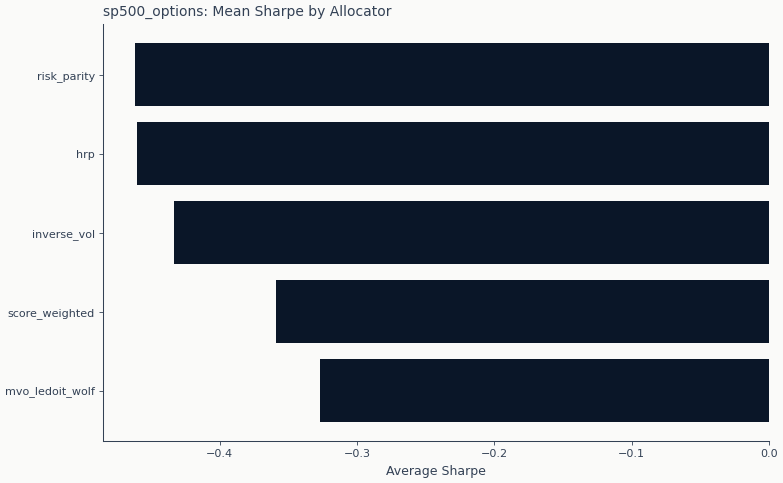

In [15]:
import matplotlib.pyplot as plt

if not alloc_comparison.is_empty():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(alloc_comparison["allocator"].to_list(), alloc_comparison["avg_sharpe"].to_list())
    ax.set_xlabel("Average Sharpe")
    ax.set_title(f"{CASE_STUDY_ID}: Mean Sharpe by Allocator")
    fig.tight_layout()
    fig.show()

### Top 10 Combinations

The best (prediction × concentration × allocator) combinations under the
HTM engine. This table checks whether an alternative improves on its advancing
liquid-universe baseline.

In [16]:
top10 = explorer.best(stage="allocation", top_n=10)
print(top10.select("backtest_hash", "prediction_hash", "source", "sharpe", "cagr", "max_drawdown"))

shape: (10, 6)
┌───────────────┬─────────────────┬─────────────────────────┬───────────┬───────────┬──────────────┐
│ backtest_hash ┆ prediction_hash ┆ source                  ┆ sharpe    ┆ cagr      ┆ max_drawdown │
│ ---           ┆ ---             ┆ ---                     ┆ ---       ┆ ---       ┆ ---          │
│ str           ┆ str             ┆ str                     ┆ f64       ┆ f64       ┆ f64          │
╞═══════════════╪═════════════════╪═════════════════════════╪═══════════╪═══════════╪══════════════╡
│ d7eaea3c1ad8  ┆ 09af9a2b2fd0    ┆ linear/ridge_a10000000. ┆ 0.001681  ┆ -0.788842 ┆ -0.996068    │
│               ┆                 ┆ 0                       ┆           ┆           ┆              │
│ 8f5a59abe732  ┆ 09af9a2b2fd0    ┆ linear/ridge_a10000000. ┆ 0.001681  ┆ -0.788842 ┆ -0.996068    │
│               ┆                 ┆ 0                       ┆           ┆           ┆              │
│ 681bc158a23e  ┆ 09af9a2b2fd0    ┆ linear/ridge_a10000000. ┆ -0.009986 ┆ -0

In [17]:
allocation_surface = explorer.best(stage="allocation", top_n=n_total)
if len(allocation_surface) != n_total:
    raise RuntimeError(
        f"Allocation analysis reads {len(allocation_surface)} rows, expected {n_total}"
    )
nonnegative = allocation_surface.filter(pl.col("sharpe") >= 0)
print(
    f"Allocation surface: {len(allocation_surface)} rows, "
    f"nonnegative={len(nonnegative)}, best={allocation_surface['sharpe'].max():.6f}."
)

Allocation surface: 150 rows, nonnegative=2, best=0.001681.


## Key Takeaways

1. The canonical sweep completes 150 runs: ten shortlisted model configs,
   three concentration levels, and five alternative allocators, all on the
   liquid universe.
2. Shortlist construction filters to the liquid universe before ranking and
   includes both accepted deep-learning producers.
3. The allocator comparison and top-combination table above are read directly
   from the exact 150-row registry surface enforced after the sweep.
4. The live result above reports whether any allocation has nonnegative Sharpe.
   Final carrier selection compares the full validation funnel after this
   surface is complete; no holdout result enters that choice.
5. The HTM cost dispatch remains the operative trading economics: option entry
   and hedge costs accrue in premium units, not equity-style bps of notional.

**Next:** Ch18 evaluates four family champions across two universes and four
quoted-half-spread cost fractions, using % of premium as the denominator.